In [2]:
!pip install tensorflow numpy matplotlib opencv-python seaborn


In [3]:
from google.colab import files
files.upload()  # upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"disanayakadmkm","key":"b533e277dd3ade7ea56d12497b14ab47"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d emmarex/plantdisease
!unzip plantdisease.zip -d plant_disease


Streaming output truncated to the last 5000 lines.
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plant_

In [6]:
import os, shutil

source = "plant_disease/PlantVillage"
tomato_dir = "tomato_data"
os.makedirs(tomato_dir, exist_ok=True)

for folder in os.listdir(source):
    if folder.startswith("Tomato"):
        shutil.copytree(os.path.join(source, folder), os.path.join(tomato_dir, folder))


In [7]:
from pathlib import Path
from torchvision import datasets

# Automatically find the PlantVillage folder anywhere under /content
base_dir = Path("/content")

# Search recursively for a folder named "PlantVillage"
candidates = list(base_dir.rglob("PlantVillage"))

if not candidates:
    raise FileNotFoundError("❌ Couldn't find a folder named 'PlantVillage' under /content.")
else:
    DATASET_ROOT = candidates[0]
    print(f"✅ Found dataset folder at: {DATASET_ROOT}")

# Create dataset
raw_ds = datasets.ImageFolder(str(DATASET_ROOT))
class_names = raw_ds.classes

print(f"✅ Classes: {len(class_names)}")
print("✅ First 5 classes:", class_names[:5])


✅ Found dataset folder at: /content/plant_disease/PlantVillage
✅ Classes: 15
✅ First 5 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


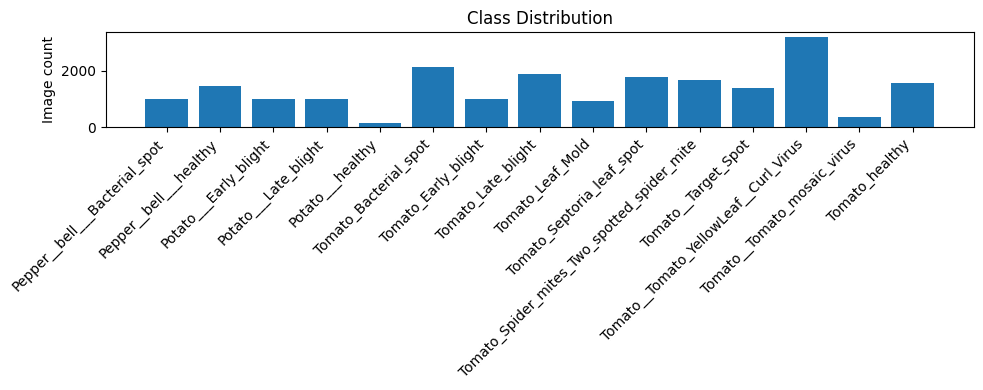

✅ Total classes: 15
✅ Total images: 20639


In [8]:
from collections import Counter
import matplotlib.pyplot as plt

# Count images per class by scanning the folders
counts = {}
for i, cls in enumerate(class_names):
    cls_dir = DATASET_ROOT / cls
    n = sum(len(files) for _, _, files in os.walk(cls_dir))
    counts[cls] = n

# Plot
plt.figure(figsize=(10, 4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel("Image count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

print("✅ Total classes:", len(counts))
print("✅ Total images:", sum(counts.values()))

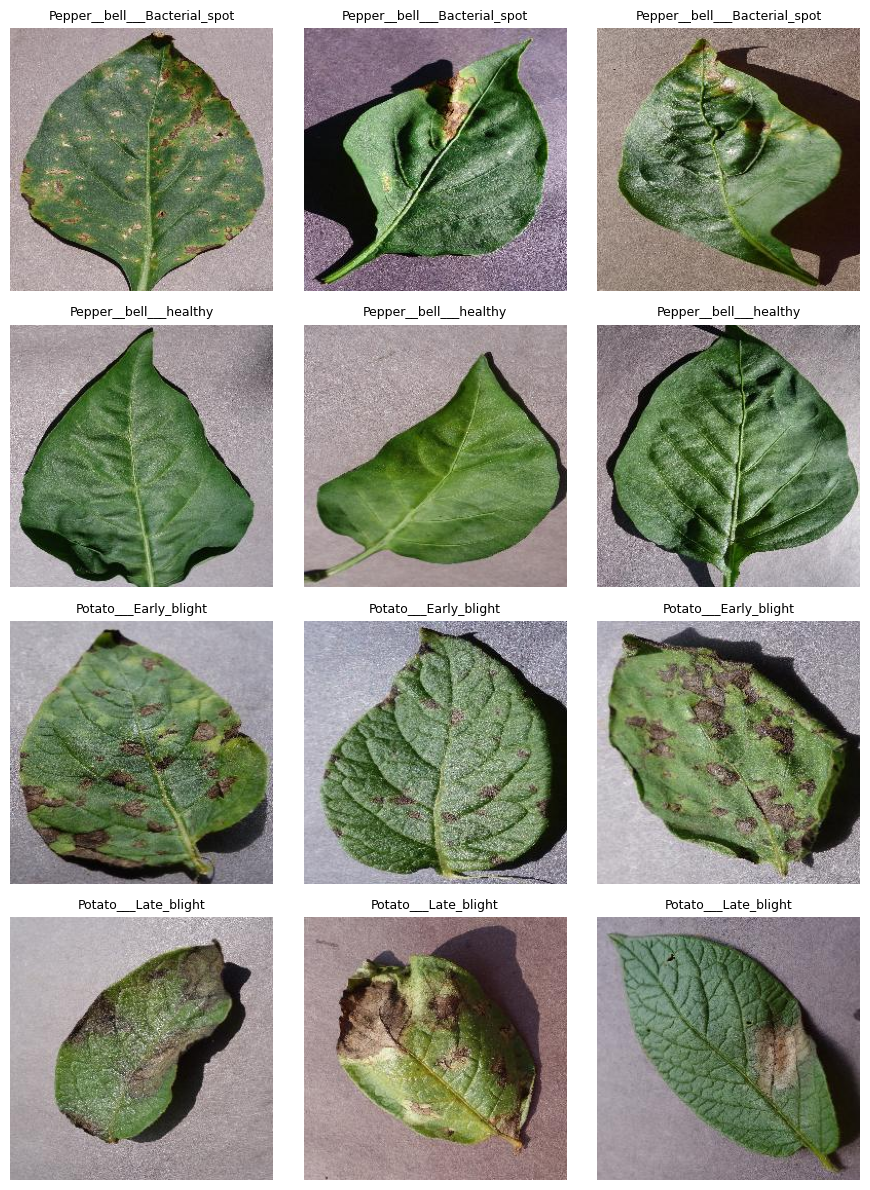

In [9]:
from PIL import Image
import random

def show_samples_per_class(root: Path, classes, n_per_class=3):
    """Show n_per_class random images from each class (limited to 4 classes to keep it light)."""
    classes_to_show = classes[:4] if len(classes) > 4 else classes
    fig, axes = plt.subplots(len(classes_to_show), n_per_class, figsize=(3*n_per_class, 3*len(classes_to_show)))
    if len(classes_to_show) == 1:
        axes = [axes]  # make it iterable

    for r, cls in enumerate(classes_to_show):
        cls_dir = root / cls
        # list all files (basic filter)
        files = []
        for dp, _, fnames in os.walk(cls_dir):
            for f in fnames:
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    files.append(os.path.join(dp, f))
        random.shuffle(files)
        take = files[:n_per_class]

        for c in range(n_per_class):
            ax = axes[r][c] if len(classes_to_show) > 1 else axes[c]
            if c < len(take):
                try:
                    img = Image.open(take[c]).convert("RGB")
                    ax.imshow(img)
                    ax.set_title(cls, fontsize=9)
                except Exception as e:
                    ax.text(0.5, 0.5, "Load error", ha='center', va='center')
                    print(f"[warn] failed to load: {take[c]} -> {e}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples_per_class(DATASET_ROOT, class_names, n_per_class=3)

In [10]:
bad_files = []
for cls in class_names:
    cls_dir = DATASET_ROOT / cls

    checked = 0
    for dp, _, fnames in os.walk(cls_dir):
        for f in fnames:
            if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            p = os.path.join(dp, f)
            try:
                with Image.open(p) as im:
                    im.verify()  # PIL integrity check
            except Exception:
                bad_files.append(p)
            checked += 1
            if checked >= 50:
                break
        if checked >= 50:
            break

print(f"✅ Quick integrity check done. Problem files found: {len(bad_files)}")
if bad_files[:5]:
    print("Examples:", bad_files[:5])

✅ Quick integrity check done. Problem files found: 0


In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import datasets

# Make sure DATASET_ROOT exists from previous steps
print("DATASET_ROOT:", DATASET_ROOT)

# Build a bare ImageFolder to get file paths and labels
base_ds = datasets.ImageFolder(str(DATASET_ROOT))
y = np.array([lbl for _, lbl in base_ds.samples])
idx = np.arange(len(base_ds.samples))

# 70/15/15 split: first carve out 15% test, then 15% of total as val
# (15% of total = 0.15/0.85 ≈ 0.1765 of the remaining)
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.15, random_state=42, stratify=y
)
y_trainval = y[idx_trainval]

val_ratio_within_trainval = 0.15 / 0.85  # ≈ 0.17647
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=val_ratio_within_trainval,
    random_state=42,
    stratify=y_trainval
)

print(f"Total: {len(idx)} | Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# (Optional) save split indices so you can reuse the same split later
from pathlib import Path
import json

split_path = ("results" / "outputs" / "split_indices.json")
split_path.parent.mkdir(parents=True, exist_ok=True)
with open(split_path, "w") as f:
    json.dump({
        "train": idx_train.tolist(),
        "val": idx_val.tolist(),
        "test": idx_test.tolist()
    }, f)
print("✅ Saved split indices to:", split_path)

DATASET_ROOT: /content/plant_disease/PlantVillage
Total: 20638 | Train: 14446 | Val: 3096 | Test: 3096


TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [15]:
# --- STEP 5: transforms & dataloaders ---

import torch
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets
from PIL import ImageFile

# Avoid issues with a few corrupted/truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Standard ImageNet-size & normalization (works for transfer learning later)
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

# Two ImageFolders: one uses train transforms, one uses eval transforms
train_folder = datasets.ImageFolder(str(DATASET_ROOT), transform=train_tfms)
eval_folder  = datasets.ImageFolder(str(DATASET_ROOT), transform=eval_tfms)

# Wrap with Subset to apply our stratified split indices
train_ds = Subset(train_folder, idx_train)
val_ds   = Subset(eval_folder,  idx_val)
test_ds  = Subset(eval_folder,  idx_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_folder.classes
num_classes = len(class_names)

print("✅ Classes:", num_classes, class_names)
print("✅ Batches -> train:", len(train_loader), "| val:", len(val_loader), "| test:", len(test_loader))


✅ Classes: 15 ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
✅ Batches -> train: 452 | val: 97 | test: 97


In [16]:
xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape, "| Batch labels:", yb.shape)



Batch images: torch.Size([32, 3, 224, 224]) | Batch labels: torch.Size([32])


In [17]:
from pathlib import Path

# Reuse project path
PROJECT_DIR = Path("/content/drive/MyDrive/crop_disease_Prediction2")

# Results folder
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(" RESULTS_DIR set to:", RESULTS_DIR)


 RESULTS_DIR set to: /content/drive/MyDrive/crop_disease_Prediction2/results


In [18]:
import os, json, csv
from pathlib import Path
from torchvision import datasets

print("DATASET_ROOT:", DATASET_ROOT)

# Build ImageFolder to read classes in a stable order
base_ds = datasets.ImageFolder(str(DATASET_ROOT))
class_names = base_ds.classes
label_map = {cls: i for i, cls in enumerate(class_names)}
print(" Classes:", len(class_names))
print(" Example mapping:", list(label_map.items())[:3])

# Save label map
(RESULTS_DIR / "outputs").mkdir(parents=True, exist_ok=True)
label_map_path = RESULTS_DIR / "outputs" / "label_map.json"
label_map_path.write_text(json.dumps(label_map, indent=2))
print(" Saved:", label_map_path)

# Save a simple CSV index: image_path, class_name, class_id
index_csv = RESULTS_DIR / "outputs" / "dataset_index.csv"
with open(index_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "class_name", "class_id"])
    for p, y in base_ds.samples:
        cls_name = class_names[y]
        writer.writerow([p, cls_name, y])
print(" Saved:", index_csv)


DATASET_ROOT: /content/plant_disease/PlantVillage
 Classes: 15
 Example mapping: [('Pepper__bell___Bacterial_spot', 0), ('Pepper__bell___healthy', 1), ('Potato___Early_blight', 2)]
 Saved: /content/drive/MyDrive/crop_disease_Prediction2/results/outputs/label_map.json
 Saved: /content/drive/MyDrive/crop_disease_Prediction2/results/outputs/dataset_index.csv


In [19]:
from PIL import Image

bad_zero_bytes = []
bad_unreadable = []
bad_ext = []

valid_ext = (".jpg", ".jpeg", ".png")

for cls in class_names:
    cls_dir = DATASET_ROOT / cls
    for dp, _, files in os.walk(cls_dir):
        for f in files:
            p = os.path.join(dp, f)
            if not f.lower().endswith(valid_ext):
                bad_ext.append(p);
                continue
            # zero-byte
            try:
                if os.path.getsize(p) == 0:
                    bad_zero_bytes.append(p)
                    continue
            except Exception:
                bad_zero_bytes.append(p)
                continue
            # unreadable
            try:
                with Image.open(p) as im:
                    im.verify()   # PIL integrity check
            except Exception:
                bad_unreadable.append(p)

print(" Missing/Invalid summary")
print("  Non-image extension:", len(bad_ext))
print("  Zero-byte files:", len(bad_zero_bytes))
print("  Unreadable/corrupt:", len(bad_unreadable))

# Save reports
report_dir = RESULTS_DIR / "outputs"
(report_dir / "bad_non_image.txt").write_text("\n".join(bad_ext))
(report_dir / "bad_zero_bytes.txt").write_text("\n".join(bad_zero_bytes))
(report_dir / "bad_unreadable.txt").write_text("\n".join(bad_unreadable))
print(" Reports saved into:", report_dir)


 Missing/Invalid summary
  Non-image extension: 1
  Zero-byte files: 0
  Unreadable/corrupt: 0
 Reports saved into: /content/drive/MyDrive/crop_disease_Prediction2/results/outputs


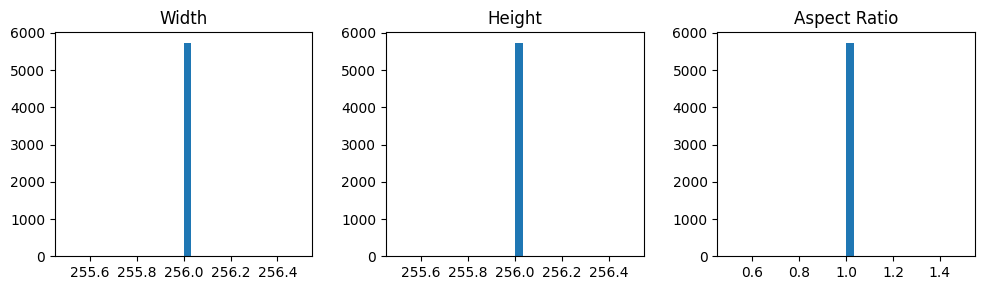

Width 1–99% ~ [256, 256]
Height 1–99% ~ [256, 256]
Aspect 1–99% ~ [1.00, 1.00]


In [20]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

widths, heights, ratios = [], [], []
sampled_paths = []

# Light scan: limit max files per class for speed
MAX_PER_CLASS = 400

for cls in class_names:
    cls_dir = DATASET_ROOT / cls
    count = 0
    for dp, _, files in os.walk(cls_dir):
        for f in files:
            if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            p = os.path.join(dp, f)
            try:
                with Image.open(p) as im:
                    w, h = im.size
                widths.append(w); heights.append(h)
                ratios.append(w / max(h, 1))
                sampled_paths.append(p)
            except Exception:
                pass
            count += 1
            if count >= MAX_PER_CLASS:
                break
        if count >= MAX_PER_CLASS:
            break

widths = np.array(widths); heights = np.array(heights); ratios = np.array(ratios)

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.hist(widths, bins=30); plt.title("Width")
plt.subplot(1,3,2); plt.hist(heights, bins=30); plt.title("Height")
plt.subplot(1,3,3); plt.hist(ratios, bins=30); plt.title("Aspect Ratio")
plt.tight_layout()

out_dir = RESULTS_DIR / "eda_visualizations"
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(RESULTS_DIR / "eda_visualizations" / "dim_outliers_hist.png", dpi=150)
plt.show()

# Flag simple outliers
w_low, w_high = np.percentile(widths, [1, 99])
h_low, h_high = np.percentile(heights, [1, 99])
r_low, r_high = np.percentile(ratios, [1, 99])

print(f"Width 1–99% ~ [{w_low:.0f}, {w_high:.0f}]")
print(f"Height 1–99% ~ [{h_low:.0f}, {h_high:.0f}]")
print(f"Aspect 1–99% ~ [{r_low:.2f}, {r_high:.2f}]")


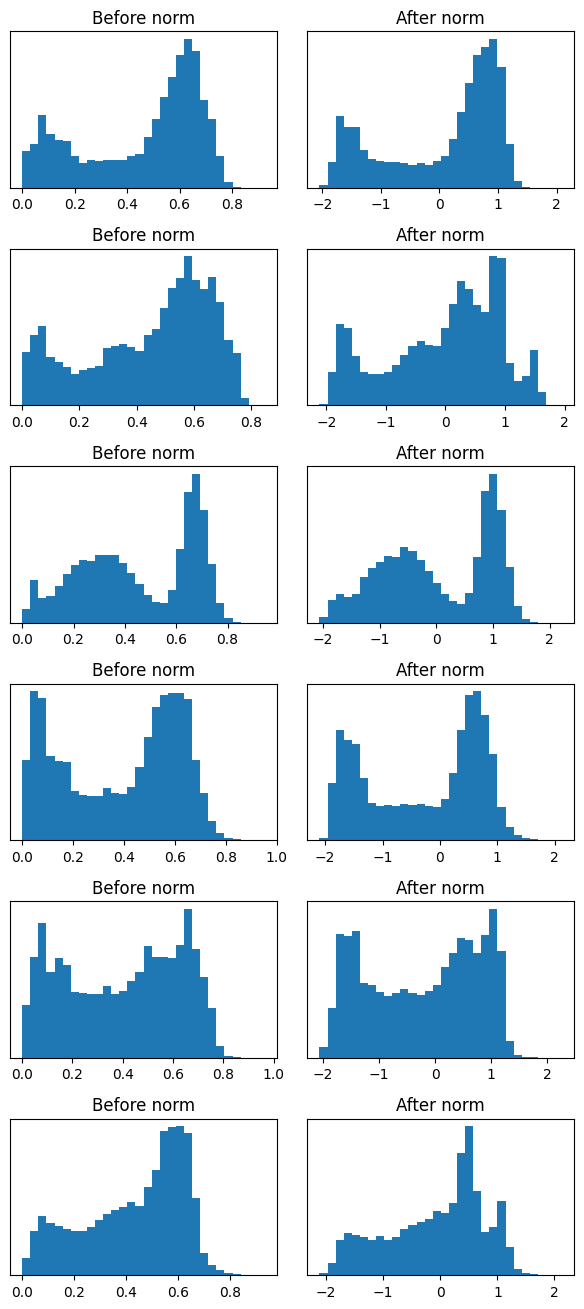

 Saved: /content/drive/MyDrive/crop_disease_Prediction2/results/eda_visualizations/normalization_demo.png


In [21]:
# --- Step 9: Show why normalization matters (simple demo on a few images) ---

import random
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np

IMG_SIZE = 224
norm = transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
to_tensor = transforms.ToTensor()
resize = transforms.Resize((IMG_SIZE, IMG_SIZE))

# pick a few random images
rand_files = []
for cls in class_names:
    cls_dir = DATASET_ROOT / cls
    for dp, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                rand_files.append(os.path.join(dp,f))
    if len(rand_files) > 30:
        break
random.shuffle(rand_files)
rand_files = rand_files[:6]

fig, axes = plt.subplots(len(rand_files), 2, figsize=(6, 2.2*len(rand_files)))
for i, p in enumerate(rand_files):
    im = Image.open(p).convert("RGB")
    x = to_tensor(resize(im))
    x_norm = norm(x.clone())

    # plot channel histogram (flatten)
    axes[i,0].hist(x.numpy().flatten(), bins=30)
    axes[i,0].set_title("Before norm")
    axes[i,1].hist(x_norm.numpy().flatten(), bins=30)
    axes[i,1].set_title("After norm")
    for j in range(2): axes[i,j].set_yticks([])

plt.tight_layout()
outp = RESULTS_DIR / "eda_visualizations" / "normalization_demo.png"
plt.savefig(outp, dpi=150); plt.show()
print(" Saved:", outp)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


Embeddings shape: (1000, 512)


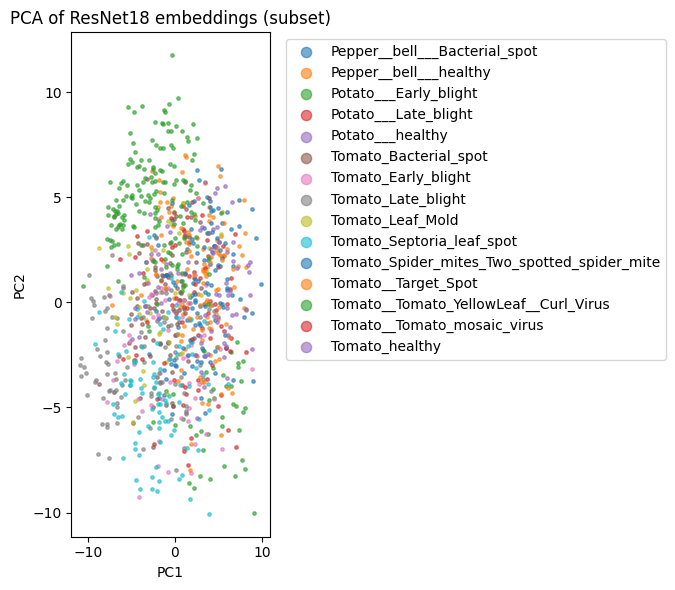

💾 Saved: /content/drive/MyDrive/crop_disease_Prediction2/results/eda_visualizations/pca_resnet18_subset.png


In [22]:
# --- Step 10: Embeddings (frozen ResNet18) + PCA scatter for EDA ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset
from sklearn.decomposition import PCA
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# small transform (no heavy aug)
IMG_SIZE = 224
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406),
                         std=(0.229,0.224,0.225)),
])

full_ds = datasets.ImageFolder(str(DATASET_ROOT), transform=eval_tfms)
class_names = full_ds.classes

# For speed, sample up to 1000 images
MAX_SAMPLES = 1000
idx_all = list(range(len(full_ds)))
random.seed(42); random.shuffle(idx_all)
idx_use = idx_all[:min(MAX_SAMPLES, len(idx_all))]
ds = Subset(full_ds, idx_use)
loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Frozen backbone
backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device)
backbone.fc = torch.nn.Identity()  # take penultimate layer (512-dim)
backbone.eval()

feats, labs = [], []
with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        v = backbone(xb)              # [B, 512]
        feats.append(v.cpu().numpy())
        labs.append(yb.numpy())
feats = np.concatenate(feats, axis=0)   # [N, 512]
labs  = np.concatenate(labs, axis=0)

print("Embeddings shape:", feats.shape)

# PCA -> 2D
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(feats)

# Plot scatter (limit legend clutter)
plt.figure(figsize=(7,6))
for cid in np.unique(labs):
    mask = labs == cid
    plt.scatter(xy[mask,0], xy[mask,1], s=6, alpha=0.6, label=class_names[cid])
plt.title("PCA of ResNet18 embeddings (subset)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
outp = RESULTS_DIR / "eda_visualizations" / "pca_resnet18_subset.png"
plt.savefig(outp, dpi=180); plt.show()
print("💾 Saved:", outp)


In [23]:


from torchvision import models
from torch import nn

def select_model(model_name, num_classes, pretrained=True):
    """
    Select and return a pretrained CNN architecture.
    """
    if model_name.lower() == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name.lower() == "vgg16":
        model = models.vgg16(pretrained=pretrained)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif model_name.lower() == "densenet121":
        model = models.densenet121(pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name.lower() == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError(f"❌ Unknown model: {model_name}")

    return model


if __name__ == "__main__":
    # Example: quick test
    num_classes = 38  # replace with len(class_names)
    model_name = "resnet18"
    model = select_model(model_name, num_classes)
    print(f"✅ Selected model: {model_name}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Selected model: resnet18


In [24]:
# 2_hyperparameter_tuning.py

import torch
from torch import nn, optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from pathlib import Path


# ✅ Load dataset
DATASET_ROOT = next(Path("/content").rglob("PlantVillage"))
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
dataset = datasets.ImageFolder(DATASET_ROOT, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# ✅ Hyperparameter tuning
learning_rates = [1e-4, 3e-4, 1e-3]
optimizers = ["adam", "sgd"]
best_acc, best_params, best_state = 0, {}, None

print("🔍 Starting hyperparameter tuning...")

for lr in learning_rates:
    for opt_type in optimizers:
        model = select_model("resnet18", num_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr) if opt_type == "adam" else optim.SGD(model.parameters(), lr=lr, momentum=0.9)

        for epoch in range(2):  # 2 quick epochs
            model.train()
            for imgs, labels in train_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(imgs), labels)
                loss.backward()
                optimizer.step()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total
        print(f"LR={lr}, OPT={opt_type}, ACC={acc:.4f}")

        if acc > best_acc:
            best_acc, best_params = acc, {"lr": lr, "opt": opt_type}
            best_state = model.state_dict().copy()

print(f"✅ Best Params: {best_params}, Acc={best_acc:.4f}")

# Save best hyperparams
torch.save({
    'best_params': best_params,
    'state_dict': best_state,
    'class_names': class_names
}, "best_tuning_result.pth")


🔍 Starting hyperparameter tuning...
LR=0.0001, OPT=adam, ACC=0.9961
LR=0.0001, OPT=sgd, ACC=0.8837
LR=0.0003, OPT=adam, ACC=0.9804
LR=0.0003, OPT=sgd, ACC=0.9641
LR=0.001, OPT=adam, ACC=0.8806
LR=0.001, OPT=sgd, ACC=0.9855
✅ Best Params: {'lr': 0.0001, 'opt': 'adam'}, Acc=0.9961


Epoch 1/5 - Loss: 0.2410 - Val Acc: 0.9864
Epoch 2/5 - Loss: 0.0303 - Val Acc: 0.9872
Epoch 3/5 - Loss: 0.0181 - Val Acc: 0.9821
Epoch 4/5 - Loss: 0.0148 - Val Acc: 0.9794
Epoch 5/5 - Loss: 0.0222 - Val Acc: 0.9910


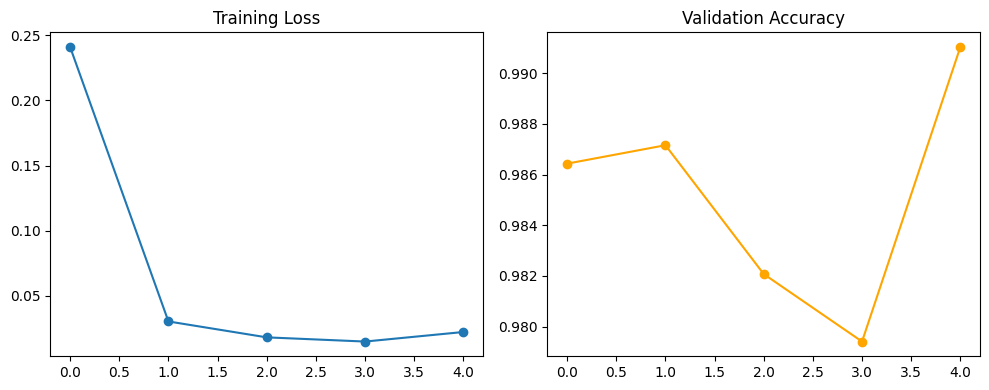

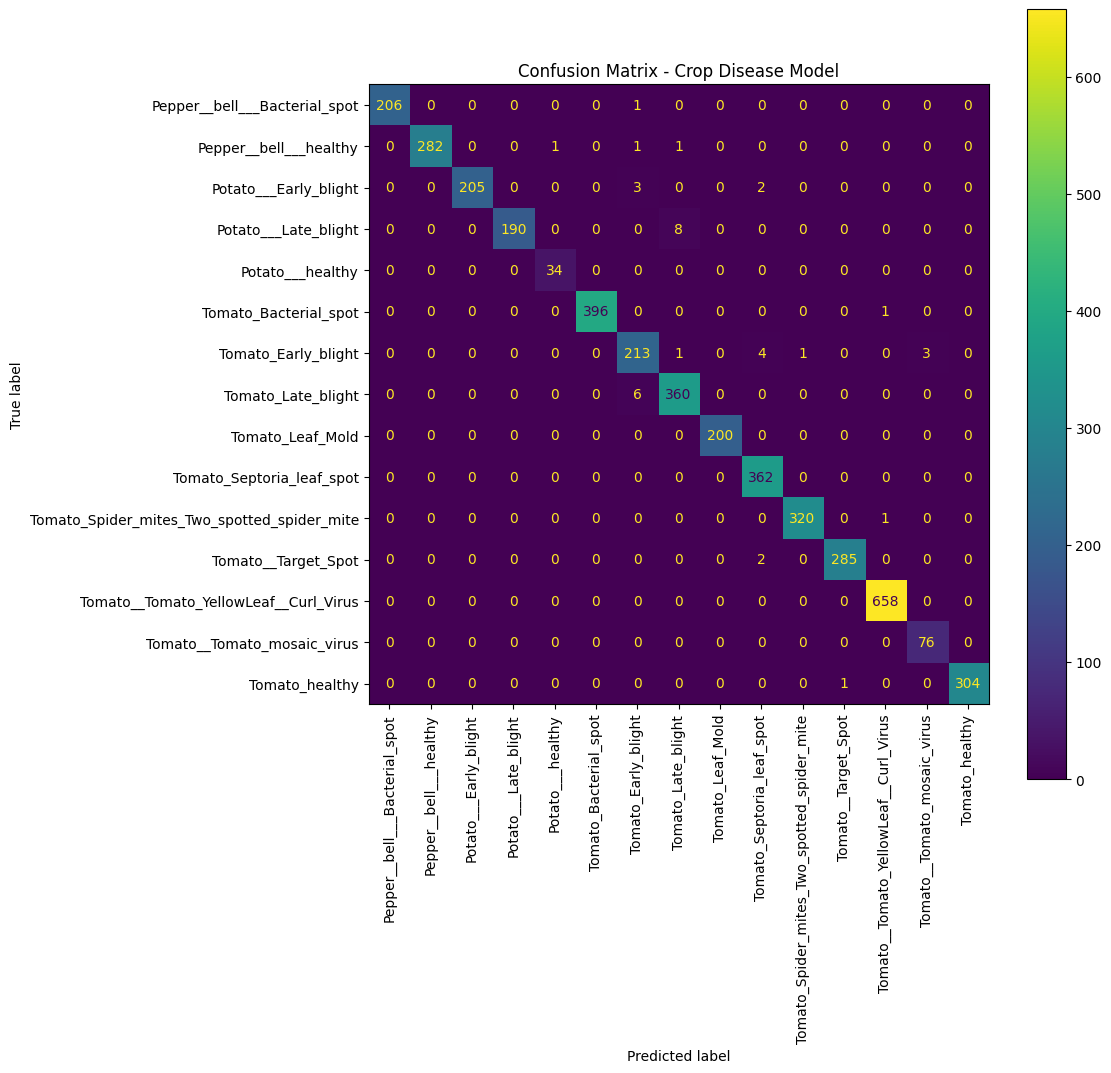

✅ Model training complete and saved as final_trained_model.pth


In [25]:
# 3_train_and_evaluate.py

import torch
from torch import nn, optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ✅ Load tuning result
checkpoint = torch.load("best_tuning_result.pth")
best_params = checkpoint['best_params']
class_names = checkpoint['class_names']

# ✅ Reload dataset
DATASET_ROOT = next(Path("/content").rglob("PlantVillage"))
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
dataset = datasets.ImageFolder(DATASET_ROOT, transform=transform)
num_classes = len(class_names)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

# ✅ Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = select_model("resnet18", num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['lr']) if best_params['opt'] == 'adam' else optim.SGD(model.parameters(), lr=best_params['lr'], momentum=0.9)

# ✅ Training
epochs = 5
train_losses, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_dl)
    train_losses.append(avg_loss)

    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Val Acc: {acc:.4f}")

# ✅ Plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies, marker='o', color='orange')
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()

# ✅ Confusion Matrix
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(cmap='viridis', ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix - Crop Disease Model")
plt.show()

torch.save(model.state_dict(), "final_trained_model.pth")
print("✅ Model training complete and saved as final_trained_model.pth")
